# Step 5 — Project SpatioTypes onto METABRIC and validate by survival

Two stages:

1. **Project SpatioType labels onto METABRIC** using the same Aitchison-distance
   centroid method as the paper. The Python reference implementation lives in
   [`../lib/clustering_helpers.py`](../lib/clustering_helpers.py)
   (`build_spatiotype_centroids` / `project_spatiotypes`); the R reference
   implementation that produced the centroids upstream is not part of this
   public repo (private path: `Cell_revisions/METABRIC/scr/spatiotypes_aitchison.r`).
2. **Validate** that the projected labels recapitulate the TCGA survival stratification
   (Figure S7B–D + the LRT for SpatioType beyond NPI).

The projection works as follows:
- Build TCGA SpatioType centroids in CLR (centered-log-ratio) space, after adding a
  1e-6 pseudocount and closure-normalising — i.e. the geometric mean of the
  cluster-proportion vectors within each SpatioType, expressed as an Aitchison
  centroid (see `compositions::acomp` in R).
- For each METABRIC patient, transform their cluster-proportion vector the same
  way and assign them to the nearest TCGA centroid (Euclidean distance in CLR
  space = Aitchison distance). Record a confidence = (d₂ − d₁) / d₂.

**Inputs (committed under `clustering_spatiotypes/data/`)**
- `tcga_spatiotypes_reference.csv` — TCGA cluster proportions + SpatioType (858 patients × 11 + SpatioType + Metacluster). Source: `spatial_clusters/original_meta_tcga.csv`.
- `metabric_cluster_props.csv` — METABRIC per-patient cluster proportions (141 patients). Produced by notebook 04.
- `metabric_survival.csv` — METABRIC clinical + RFS metadata (141 patients).

**Outputs (committed under `clustering_spatiotypes/data/`)**
- `metabric_spatiotypes.csv` — METABRIC patient → projected SpatioType + confidence.

## Setup

In [1]:
import sys
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

from clustering_helpers import (
    SPATIOTYPE_PALETTE,
    build_spatiotype_centroids,
    project_spatiotypes,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

# The METABRIC pipeline returns the short SpatioType label "Proliferative".
PALETTE = {
    "Proliferative":    SPATIOTYPE_PALETTE["Proliferation-Enriched"],
    "Immune-Modulated": SPATIOTYPE_PALETTE["Immune-Modulated"],
    "Immune-Inactive":  SPATIOTYPE_PALETTE["Immune-Inactive"],
}
ORDER = ["Proliferative", "Immune-Modulated", "Immune-Inactive"]

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Stage 1 — Build TCGA SpatioType centroids in CLR space

In [2]:
tcga = pd.read_csv("../data/tcga_spatiotypes_reference.csv", index_col=0)
tcga_cluster_cols = [c for c in tcga.columns if c.startswith("Cluster")]
centroids = build_spatiotype_centroids(
    tcga,
    spatiotype_col="SpatioType",
    cluster_cols=tcga_cluster_cols,
    keep=("Immune-Modulated", "Immune-Inactive", "Proliferative"),
)
print("Reference patients per SpatioType:")
print(tcga[tcga["SpatioType"].isin(centroids.index)]["SpatioType"].value_counts())
print()
centroids

Reference patients per SpatioType:
SpatioType
Immune-Modulated    562
Immune-Inactive     218
Proliferative        62
Name: count, dtype: int64



,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11
SpatioType,,,,,,,,,,,
Immune-Modulated,5.231759,-1.104624,-3.720720,0.744353,2.859488,0.604544,1.648908,1.923944,-3.630181,-0.817803,-3.739667
Immune-Inactive,1.216957,7.005890,-3.374536,6.156521,1.081029,-1.649186,-1.506140,-0.245075,-3.261557,-2.046795,-3.377108
Proliferative,-1.269452,-1.455605,-1.455605,-0.719608,-1.455605,-1.093363,-1.084789,-0.893739,12.338977,-1.455605,-1.455605


## Stage 2 — Project METABRIC patients onto the TCGA centroids

In [3]:
mb_props = pd.read_csv("../data/metabric_cluster_props.csv", index_col=0)
mb_cluster_cols = [c for c in mb_props.columns if c.startswith("Cluster")]

proj = project_spatiotypes(mb_props, centroids, cluster_cols=mb_cluster_cols)
proj.head()

,SpatioType,confidence
slide_name,,
MB-0008,Immune-Modulated,0.189145
MB-0050,Immune-Modulated,0.144976
MB-0060,Proliferative,0.257104
MB-0102,Immune-Modulated,0.188993
MB-0106,Immune-Modulated,0.144965


In [4]:
# Save and summarise
proj.to_csv("../data/metabric_spatiotypes.csv")
proj["SpatioType"].value_counts().reindex(ORDER)

SpatioType
Proliferative         9
Immune-Modulated    122
Immune-Inactive      10
Name: count, dtype: int64

## Stage 3 — Validate against METABRIC RFS

Merge the projected SpatioType with METABRIC survival metadata.

In [5]:
surv = pd.read_csv("../data/metabric_survival.csv", index_col=0)

# Use the projected SpatioType (not the pre-saved label from the upstream R run).
df = surv.drop(columns=["SpatioType"], errors="ignore").join(proj[["SpatioType"]], how="inner")
df["event"] = (df["RFS_STATUS"] == "1:Recurred").astype(int)
print("Cohort:", len(df))
df["SpatioType"].value_counts().reindex(ORDER)

Cohort: 141


SpatioType
Proliferative         9
Immune-Modulated    122
Immune-Inactive      10
Name: count, dtype: int64

### Figure S7B — Main KM

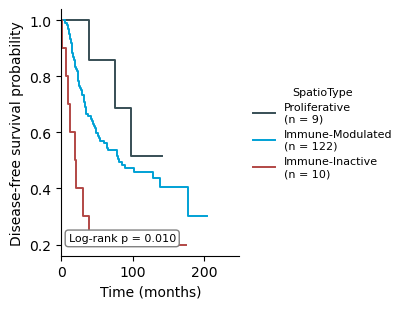

In [6]:
main = df.dropna(subset=["RFS_MONTHS", "event", "SpatioType"]).copy()

fig, ax = plt.subplots(figsize=(4.2, 3.2))
for st in ORDER:
    g = main[main["SpatioType"] == st]
    KaplanMeierFitter().fit(
        durations=g["RFS_MONTHS"], event_observed=g["event"],
        label=f"{st}\n(n = {len(g)})",
    ).plot_survival_function(ax=ax, color=PALETTE[st], linewidth=1.4, ci_show=False)

p = multivariate_logrank_test(main["RFS_MONTHS"], main["SpatioType"], main["event"]).p_value
ax.text(0.04, 0.05, f"Log-rank p = {p:.3f}", transform=ax.transAxes,
        fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

ax.set(xlabel="Time (months)", ylabel="Disease-free survival probability")
ax.set_xlim(0, 250)
ax.legend(title="SpatioType", loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=8, title_fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### Cox HR for Immune-Inactive (adjusted for stage + Age > 65)

In [7]:
cox_df = main.dropna(subset=["Age", "Tumor_stage"]).copy()
cox_df["stage_num"] = pd.to_numeric(cox_df["Tumor_stage"], errors="coerce")
cox_df["AGE_65"]    = (cox_df["Age"] > 65).astype(int)
cox_df = cox_df.dropna(subset=["stage_num"])
cox_df["SpatioType_cat"] = pd.Categorical(cox_df["SpatioType"], categories=ORDER)

cox_in = pd.get_dummies(
    cox_df[["SpatioType_cat", "stage_num", "AGE_65", "RFS_MONTHS", "event"]],
    columns=["SpatioType_cat"], drop_first=True,
).astype(float)

cph = CoxPHFitter()
cph.fit(cox_in, duration_col="RFS_MONTHS", event_col="event")
cph.summary[["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(3)

,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
stage_num,0.611,1.842,1.082,3.136,0.024
AGE_65,0.668,1.950,0.836,4.549,0.122
SpatioType_cat_Immune-Modulated,0.545,1.724,0.410,7.254,0.457
SpatioType_cat_Immune-Inactive,2.265,9.628,1.830,50.645,0.008


### Figure S7C — KM by clinical subtype

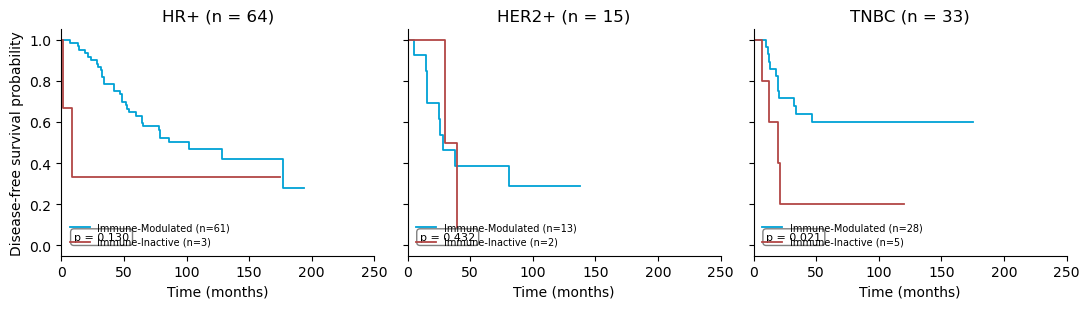

In [8]:
subtypes = ["HR+", "HER2+", "TNBC"]
sub_data = df.dropna(subset=["RFS_MONTHS", "event", "SpatioType", "clinical_subtype"]).copy()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)

for ax, st in zip(axes, subtypes):
    g_all = sub_data[sub_data["clinical_subtype"] == st]
    g_all = g_all[g_all["SpatioType"].isin(["Immune-Inactive", "Immune-Modulated"])]
    if g_all["SpatioType"].nunique() < 2 or len(g_all) < 5:
        ax.text(0.5, 0.5, "Insufficient samples", transform=ax.transAxes,
                ha="center", va="center", fontsize=8); continue
    for sp in ["Immune-Modulated", "Immune-Inactive"]:
        g = g_all[g_all["SpatioType"] == sp]
        if len(g) < 1: continue
        KaplanMeierFitter().fit(
            durations=g["RFS_MONTHS"], event_observed=g["event"],
            label=f"{sp} (n={len(g)})",
        ).plot_survival_function(ax=ax, color=PALETTE[sp], linewidth=1.3, ci_show=False)
    try:
        cd = g_all.copy()
        cd["cat"] = pd.Categorical(cd["SpatioType"], categories=["Immune-Modulated", "Immune-Inactive"])
        ci = pd.get_dummies(cd[["cat", "RFS_MONTHS", "event"]], columns=["cat"], drop_first=True).astype(float)
        cph_sub = CoxPHFitter().fit(ci, duration_col="RFS_MONTHS", event_col="event")
        coef = float(cph_sub.summary["coef"].iloc[0])
        p2   = float(cph_sub.summary["p"].iloc[0])
        p1 = p2 / 2 if coef > 0 else 1 - p2 / 2
        ax.text(0.04, 0.06, f"p = {p1:.3f}", transform=ax.transAxes,
                fontsize=8, va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))
    except Exception as e:
        print(st, "Cox failed:", e)

    ax.set(title=f"{st} (n = {len(g_all)})", xlabel="Time (months)")
    ax.set_xlim(0, 250)
    ax.legend(fontsize=7, frameon=False, loc="lower left")

axes[0].set_ylabel("Disease-free survival probability")
plt.tight_layout()
plt.show()

### Figure S7D — KM within the poor-NPI subgroup

Poor-NPI cohort: 37


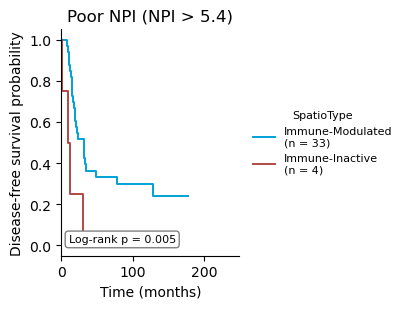

In [9]:
poor = df.dropna(subset=["RFS_MONTHS", "event", "SpatioType", "NPI"]).copy()
poor = poor[poor["NPI"] > 5.4]
poor = poor[poor["SpatioType"].isin(["Immune-Inactive", "Immune-Modulated"])]
print("Poor-NPI cohort:", len(poor))

fig, ax = plt.subplots(figsize=(4.2, 3.2))
for sp in ["Immune-Modulated", "Immune-Inactive"]:
    g = poor[poor["SpatioType"] == sp]
    KaplanMeierFitter().fit(
        durations=g["RFS_MONTHS"], event_observed=g["event"],
        label=f"{sp}\n(n = {len(g)})",
    ).plot_survival_function(ax=ax, color=PALETTE[sp], linewidth=1.4, ci_show=False)

lr = logrank_test(
    durations_A=poor[poor["SpatioType"] == "Immune-Modulated"]["RFS_MONTHS"],
    durations_B=poor[poor["SpatioType"] == "Immune-Inactive"]["RFS_MONTHS"],
    event_observed_A=poor[poor["SpatioType"] == "Immune-Modulated"]["event"],
    event_observed_B=poor[poor["SpatioType"] == "Immune-Inactive"]["event"],
)
ax.text(0.04, 0.05, f"Log-rank p = {lr.p_value:.3f}", transform=ax.transAxes,
        fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

ax.set(xlabel="Time (months)", ylabel="Disease-free survival probability",
       title="Poor NPI (NPI > 5.4)")
ax.set_xlim(0, 250)
ax.legend(title="SpatioType", loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=8, title_fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### LRT — SpatioType beyond NPI

In [10]:
from scipy.stats import chi2

base = df.dropna(subset=["RFS_MONTHS", "event", "SpatioType", "NPI"]).copy()
base["SpatioType_cat"] = pd.Categorical(base["SpatioType"], categories=ORDER)

m_full_in = pd.get_dummies(base[["SpatioType_cat", "NPI", "RFS_MONTHS", "event"]],
                           columns=["SpatioType_cat"], drop_first=True).astype(float)
m_redu_in = base[["NPI", "RFS_MONTHS", "event"]].astype(float)

cph_full = CoxPHFitter().fit(m_full_in, duration_col="RFS_MONTHS", event_col="event")
cph_redu = CoxPHFitter().fit(m_redu_in, duration_col="RFS_MONTHS", event_col="event")

lr_stat = 2 * (cph_full.log_likelihood_ - cph_redu.log_likelihood_)
dof = cph_full.params_.shape[0] - cph_redu.params_.shape[0]
p_lrt = float(chi2.sf(lr_stat, df=dof))

print(f"LRT statistic = {lr_stat:.3f}  (df={dof})")
print(f"LRT p-value   = {p_lrt:.4f}")

LRT statistic = 6.322  (df=2)
LRT p-value   = 0.0424
